# Project FORESIGHT — Phase 11: Final Forecasting Model Selection

Consolidation of Phases 8–10. Frozen Phase 8 LightGBM and Phase 9 stability remain immutable.


## 1. Load registry and metadata

In [1]:
import os, sys, json
import pandas as pd
from IPython.display import Image, display

BASE_DIR = os.path.abspath(".")
if os.path.basename(BASE_DIR) == "notebooks":
    BASE_DIR = os.path.abspath("..")
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

from src.phase11_common import (
    CANDIDATE_PATH, FIGURES_FINAL_DIR, FINAL_PRED_PATH, FORECASTS_FINAL_DIR,
    METADATA_PATH, REGISTRY_PATH, REPORT_PATH,
)
from src.validate_final_forecasting import run_validation

meta = json.load(open(METADATA_PATH, encoding="utf-8"))
reg = json.load(open(REGISTRY_PATH, encoding="utf-8"))
print("readiness", meta["production_readiness"])
print("UCI", meta["final_uci_model"])
print("SYNTHETIC", meta["final_synthetic_model"])
print("horizon", meta["horizon_strategy"])
print("phase8_unchanged", meta.get("phase8_unchanged"), "phase9_unchanged", meta.get("phase9_unchanged"))
print("n_models", len(reg))
print(pd.DataFrame(reg)[["model_id", "dataset", "horizon", "model_type", "status"]].to_string(index=False))


readiness READY WITH MONITORING
UCI uci_h1_phase8_lightgbm
SYNTHETIC synthetic_h1_hurdle_th050
horizon {'h=1_UCI': 'Phase8_LightGBM', 'h=1_SYNTHETIC': 'Hurdle_th0.50', 'h=3_7_14_30': 'Direct_LightGBM'}
phase8_unchanged True phase9_unchanged True
n_models 12
                     model_id   dataset  horizon         model_type             status
       uci_h1_phase8_lightgbm       UCI        1     lightgbm_point           selected
    synthetic_h1_hurdle_th050 SYNTHETIC        1             hurdle           selected
       uci_h3_direct_lightgbm       UCI        3    direct_lightgbm           selected
       uci_h7_direct_lightgbm       UCI        7    direct_lightgbm           selected
      uci_h14_direct_lightgbm       UCI       14    direct_lightgbm           selected
      uci_h30_direct_lightgbm       UCI       30    direct_lightgbm           selected
       uci_h1_quantile_p10p90       UCI        1 quantile_intervals interval_companion
 synthetic_h3_direct_lightgbm SYNTHETIC       

## 2. Candidate matrix and selection

In [2]:
cand = pd.read_parquet(CANDIDATE_PATH)
print(cand.to_string(index=False))
print("--- selected ---")
print(pd.read_parquet(os.path.join(FORECASTS_FINAL_DIR, "selection_table.parquet")).to_string(index=False))


  dataset                     model  horizon     MAE     RMSE    sMAPE     WAPE    bias  zero_demand_MAE  positive_demand_MAE           training_time inference_time                                         stability  prediction_interval_availability                                 complexity  implemented  eligible                                                                exclude_reason                                                 source_artifact
      UCI           Phase8_LightGBM        1 17.3447  70.8952  82.8734  79.4710     NaN              NaN                  NaN                  frozen            n/a         Stable (Phase 9 folds; fold-2 WAPE spike)                             False single LightGBM + freq-encode preprocessor         True      True                                                                           NaN              data/processed/forecasts/ml/ml_predictions.parquet
SYNTHETIC           Phase8_LightGBM        1  2.8156   5.1469 113.6813  38.8923     Na

## 3. Final performance

  Dataset          Baseline  Baseline WAPE  Final Model WAPE  Absolute improvement  Improvement %
      UCI moving_average_30        86.3870           79.4710                6.9160         8.0058
SYNTHETIC             naive        72.8181           26.2505               46.5676        63.9506
  dataset  horizon                     model     MAE    RMSE     MAPE   sMAPE    WAPE      n    bias  mean_residual  median_residual  residual_std  overprediction_pct  underprediction_pct  n_zero  n_nonzero  zero_share_pct  zero_mae  nonzero_mae  zero_positive_prediction_rate  predicted_zero_rate  actual_zero_rate  counts_reconcile
SYNTHETIC        1 synthetic_h1_hurdle_th050  1.9004  5.0573  29.4059 13.5443 26.2505 147000 -0.2557         0.2557           0.0000        5.0509               19.84                19.76   90070      56930           61.27       0.3       4.4324                           1.42                62.39             61.27                 1
      UCI        1    uci_h1_phase8_li

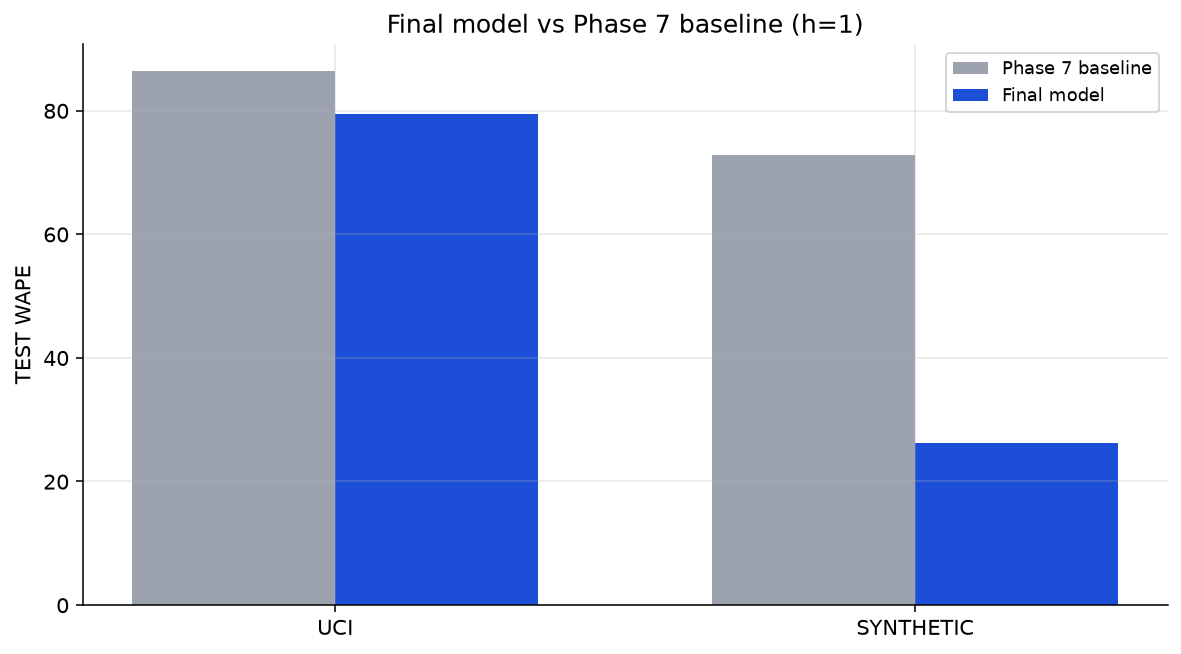

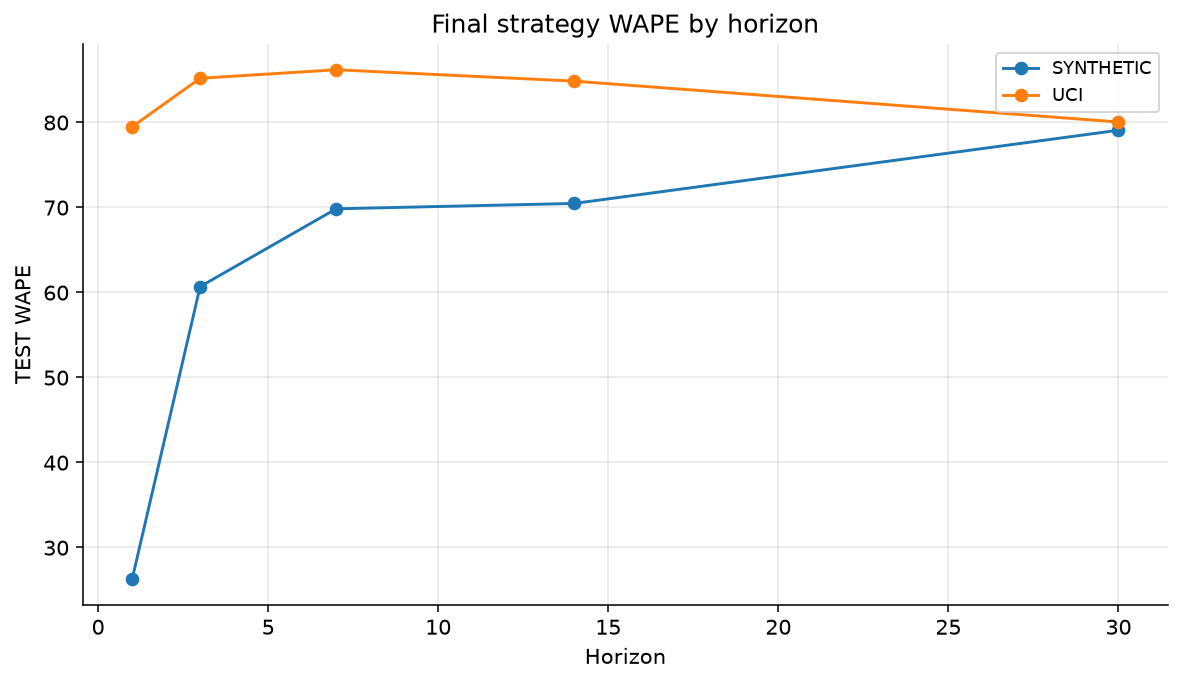

In [3]:
print(pd.read_parquet(os.path.join(FORECASTS_FINAL_DIR, "analysis_baseline.parquet")).to_string(index=False))
print(pd.read_parquet(os.path.join(FORECASTS_FINAL_DIR, "analysis_overall_h1.parquet")).to_string(index=False))
print(pd.read_parquet(os.path.join(FORECASTS_FINAL_DIR, "analysis_horizon.parquet")).to_string(index=False))
display(Image(os.path.join(FIGURES_FINAL_DIR, "final_model_comparison.png")))
display(Image(os.path.join(FIGURES_FINAL_DIR, "final_horizon_comparison.png")))


## 4. Error analysis

  dataset  mean_bias  median_bias  mean_residual  median_residual  overprediction_pct  underprediction_pct
SYNTHETIC    -0.2557       0.0000         0.2557           0.0000               19.84                19.76
      UCI     0.0335       3.8346        -0.0335          -3.8346               71.72                28.28
  dataset regime  model     MAE     RMSE     MAPE    sMAPE     WAPE     n     bias  mean_residual  median_residual  residual_std  overprediction_pct  underprediction_pct  n_zero  n_nonzero  zero_share_pct  zero_mae  nonzero_mae  zero_positive_prediction_rate  predicted_zero_rate  actual_zero_rate  counts_reconcile
SYNTHETIC   high   high  6.9156  11.0748  21.4398  30.0431  21.7297 17723  -4.8362         4.8362           3.0357        9.9634               28.44                71.56       0      17723             0.0       NaN       6.9156                            NaN                 7.62               0.0                 1
SYNTHETIC    low    low  2.7806   3.9129  42.07

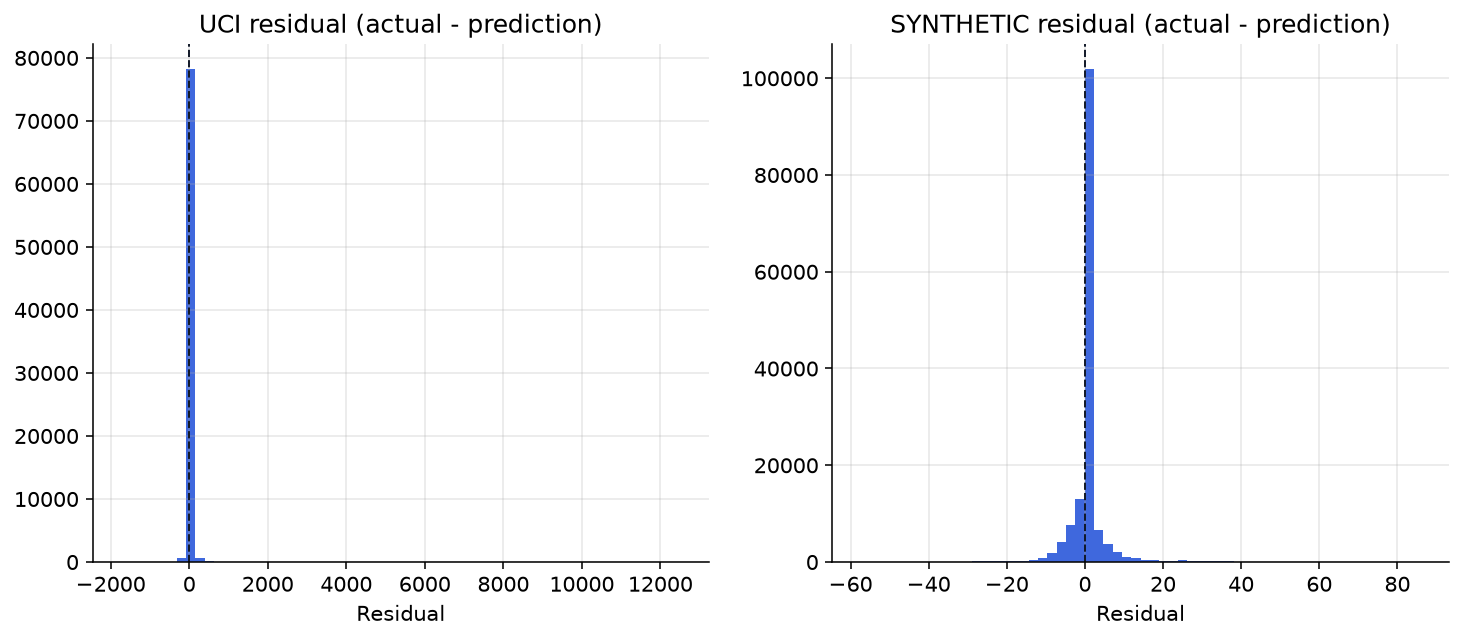

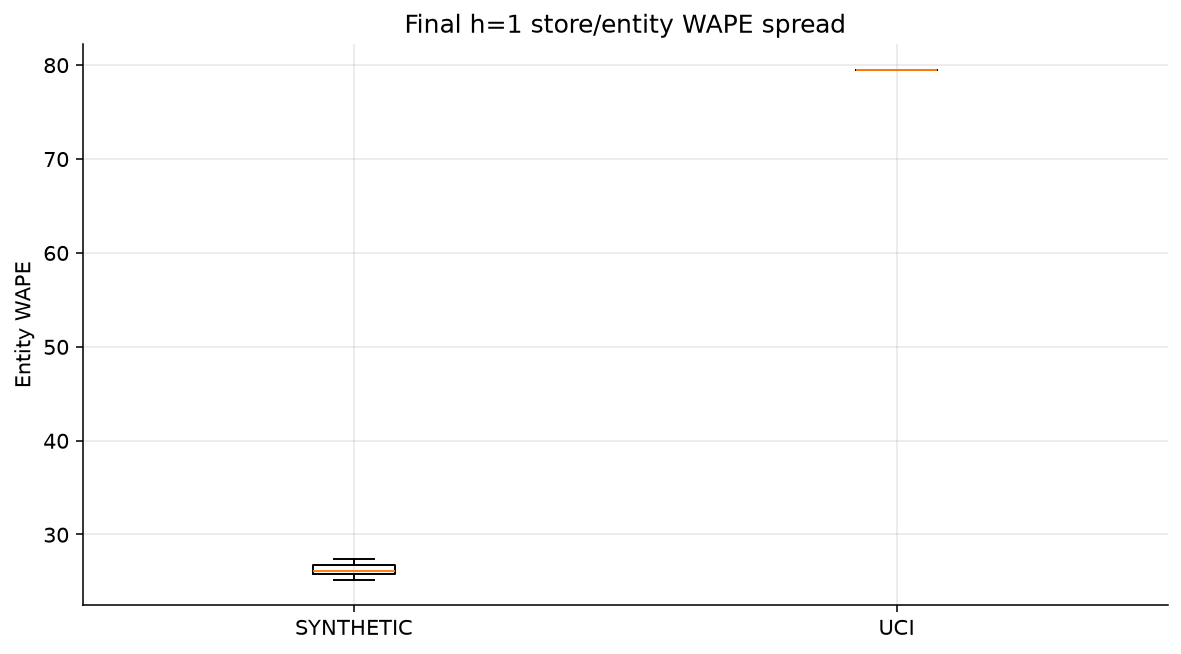

In [4]:
print(pd.read_parquet(os.path.join(FORECASTS_FINAL_DIR, "analysis_bias.parquet")).to_string(index=False))
print(pd.read_parquet(os.path.join(FORECASTS_FINAL_DIR, "analysis_regime.parquet")).to_string(index=False))
print(pd.read_parquet(os.path.join(FORECASTS_FINAL_DIR, "analysis_store_summary.parquet")).to_string(index=False))
display(Image(os.path.join(FIGURES_FINAL_DIR, "final_residual_analysis.png")))
display(Image(os.path.join(FIGURES_FINAL_DIR, "final_store_stability.png")))


## 5. Zero-demand and intervals

 side model    MAE   RMSE    MAPE   sMAPE    WAPE      n    bias  mean_residual  median_residual  residual_std  overprediction_pct  underprediction_pct  n_zero  n_nonzero  zero_share_pct  zero_mae  nonzero_mae  zero_positive_prediction_rate  predicted_zero_rate  actual_zero_rate  counts_reconcile  n_matched
final final 1.9004 5.0573 29.4059 13.5443 26.2505 147000 -0.2557         0.2557              0.0        5.0509               19.84                19.76   90070      56930           61.27       0.3       4.4324                           1.42                62.39             61.27                 1     147000


  side  model    MAE   RMSE    MAPE    sMAPE    WAPE      n   bias  mean_residual  median_residual  residual_std  overprediction_pct  underprediction_pct  n_zero  n_nonzero  zero_share_pct  zero_mae  nonzero_mae  zero_positive_prediction_rate  predicted_zero_rate  actual_zero_rate  counts_reconcile  n_matched
phase8 phase8 2.8156 5.1469 30.4648 113.6813 38.8923 147000 0.0873        -0.0873          -0.5393        5.1461               67.24                22.12   90070      56930           61.27    1.4444        4.985                          82.64                10.64             61.27                 1     147000
  dataset      n  coverage_pct  nominal_coverage_pct  mean_width  pinball_p10  pinball_p50  pinball_p90  p10_below_pct  p90_below_pct  interval_crossing
SYNTHETIC 147000       89.7673                  80.0     10.0079       0.4652       1.2379       0.8975          64.04          93.80                  0
      UCI  79545       82.3672                  80.0     39.4081       2

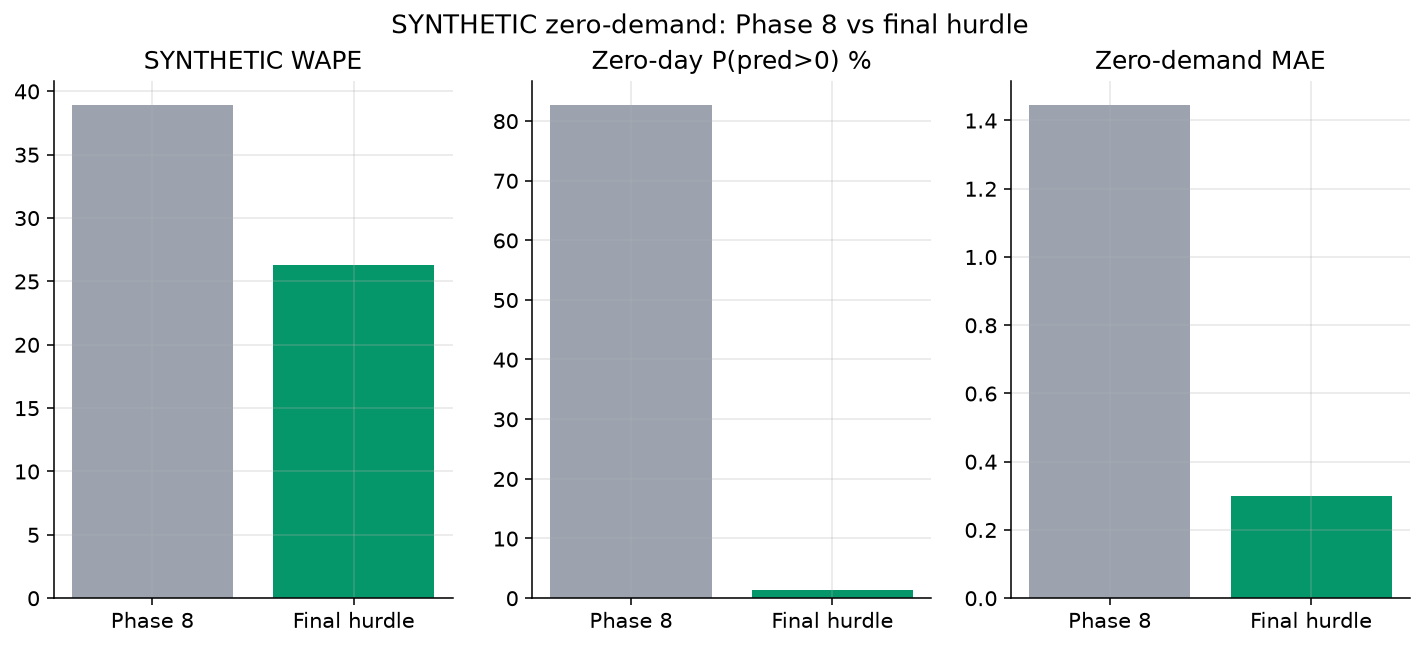

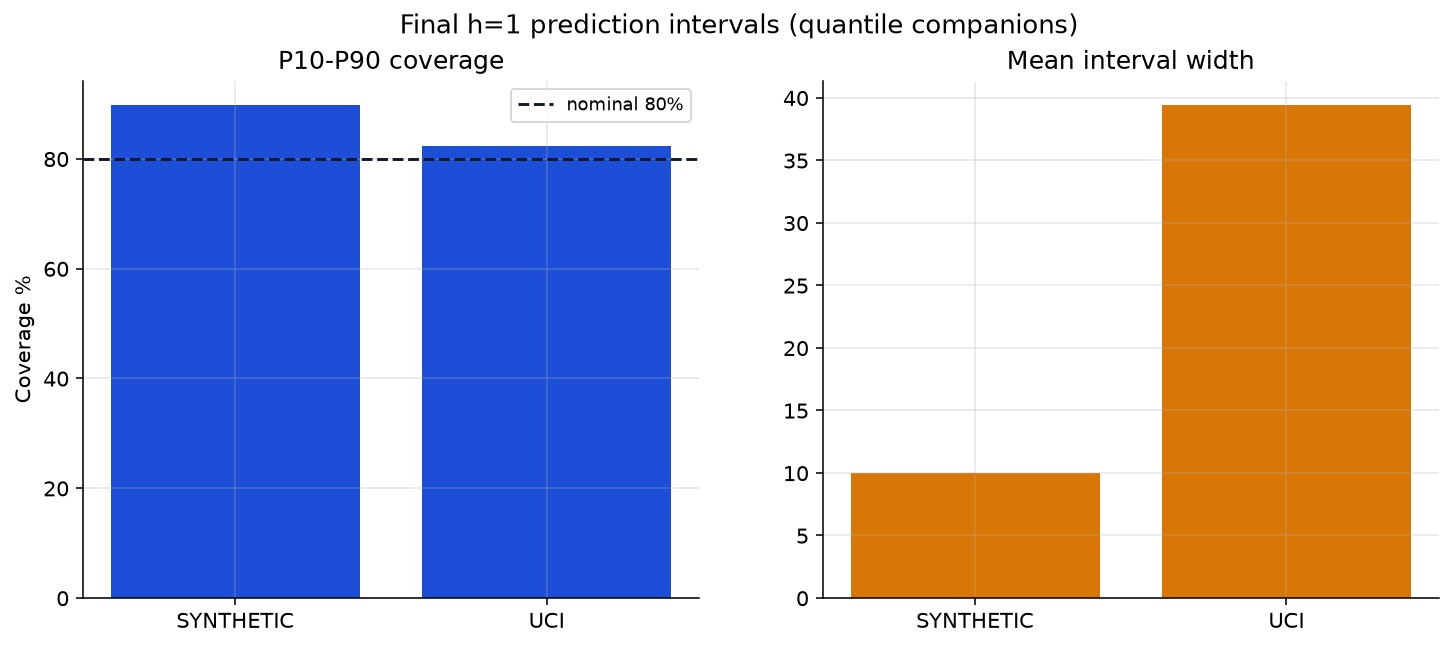

In [5]:
print(pd.read_parquet(os.path.join(FORECASTS_FINAL_DIR, "analysis_zero_final.parquet")).to_string(index=False))
print(pd.read_parquet(os.path.join(FORECASTS_FINAL_DIR, "analysis_zero_phase8.parquet")).to_string(index=False))
print(pd.read_parquet(os.path.join(FORECASTS_FINAL_DIR, "analysis_intervals.parquet")).to_string(index=False))
display(Image(os.path.join(FIGURES_FINAL_DIR, "final_zero_demand_comparison.png")))
display(Image(os.path.join(FIGURES_FINAL_DIR, "final_prediction_intervals.png")))


## 6. Validation

In [6]:
result = run_validation()
print("VALIDATION", result.summary())
assert result.failed == 0
print("Phase 11 COMPLETE — STOP. Do not start another modeling phase.")


PHASE 11 FINAL VALIDATION

[1] Phase 10 / freeze
  [+] Phase 10 complete and frozen


  [+] Phase 8 hashes unchanged after Phase 11 -- []
  [+] Phase 9 hashes unchanged after Phase 11 -- []
  [+] metadata.phase8_unchanged
  [+] metadata.phase9_unchanged

[2] Model integrity
  [+] registry exists
  [+] models/final exists
  [+] registry is a list
  [+] model_id unique
  [+] has UCI h=1 Phase 8 model
  [+] has SYNTHETIC hurdle
  [+] has 8 direct models
  [+] has two interval companions
  [+] final dir file count matches registry -- 12 vs 12
  [+] uci_h1_phase8_lightgbm file exists
  [+] uci_h1_phase8_lightgbm hash matches registry -- 331909f0fe191c0b9cb0418884b25eb59012f479f61f8b3e2ad51b729273e90d vs 331909f0fe191c0b9cb0418884b25eb59012f479f61f8b3e2ad51b729273e90d
  [+] uci_h1_phase8_lightgbm loads
  [+] uci_h1_phase8_lightgbm has required features list
  [+] uci_h1_phase8_lightgbm no leakage features -- []
  [+] uci_h1_phase8_lightgbm units_sold not a feature
  [+] synthetic_h1_hurdle_th050 file exists
  [+] synthetic_h1_hurdle_th050 hash matches registry -- 59a2b7202486

  [+] schema column forecast_date
  [+] schema column source_dataset
  [+] schema column entity_id
  [+] schema column product_key
  [+] schema column horizon
  [+] schema column actual
  [+] schema column prediction
  [+] schema column lower_bound
  [+] schema column upper_bound
  [+] schema column model_name
  [+] schema column model_version
  [+] predictions finite
  [+] predictions non-negative
  [+] horizons in {1,3,7,14,30}


  [+] no duplicate forecast keys -- dup=0
  [+] dates valid
  [+] no null predictions


  [+] h=1 has both datasets
  [+] interval lower <= upper
  [+] interval bounds non-negative


  [+] UCI h=1 matches Phase 8 row count
  [+] UCI h=1 matches Phase 8 predictions -- max_abs_diff=0.0
  [+] SYNTHETIC h=1 n=147000 -- n=147000
  [+] SYNTHETIC hurdle close to Phase 10 -- max_abs_diff=0.0

[4] Data integrity / docs
  [+] candidate matrix exists
  [+] report exists
  [+] monitoring plan exists
  [+] report has ## 1. Executive Summary
  [+] report has ## 5. Final Model Selection
  [+] report has ## 7. Zero-Demand Results
  [+] report has ## 12. Production Readiness
  [+] readiness is READY WITH MONITORING
  [+] report does not claim READY without monitoring
  [+] figure final_model_comparison.png
  [+] figure final_horizon_comparison.png
  [+] figure final_store_stability.png
  [+] figure final_residual_analysis.png
  [+] figure final_zero_demand_comparison.png
  [+] figure final_prediction_intervals.png

[5] Leakage
  [+] forbidden columns documented
  [+] hurdle features exclude units_sold
  [+] direct features exclude units_sold
  [+] direct uses hcal calendar

[6] Inp

  [+] valid UCI sample predicts
  [+] rejects missing lag
  [+] rejects duplicate keys
  [+] rejects negative lag
  [+] rejects missing lag_1 values

[7] Reproducibility


  [+] identical predictions on repeat -- max_abs_diff=0.0


  [+] hurdle identical on repeat -- max_abs_diff=0.0

[8] Metrics vs Phase 8 reference
  [+] Phase 8 UCI WAPE reference
  [+] Phase 8 SYNTHETIC WAPE reference
  [+] SYNTHETIC final WAPE near hurdle 26.25 -- WAPE=26.2505

VALIDATION RESULT: 140/140 PASS


VALIDATION 140/140 PASS
Phase 11 COMPLETE — STOP. Do not start another modeling phase.
